# Nivel 5. Razonamiento cognitivo y conclusiones (LangGraph)

Este notebook traduce los resultados analíticos en conclusiones operacionales mediante un grafo de
razonamiento LangGraph definido en `src/reasoning/`. El notebook solo invoca el grafo y muestra su
salida; la lógica vive en los módulos.

El grafo usa un estado tipado (`TypedDict`) y nodos diferenciados:

1. `validate`: valida el punto de operación contra las variables esperadas (sensores base, feeds y
   sílice reciente), sus límites físicos y el rango histórico observado.
2. `predict`: predicción del modelo y comparación con la última medición de laboratorio.
3. `drivers`: drivers SHAP locales de esa predicción, en escala de cambio respecto a la hora anterior.
4. `scenarios`: barridos what-if sobre las variables manipulables (impacto alcanzable).
5. `synthesize`: informe final con impacto estimado.

Una arista condicional tras `validate` desvía las entradas inválidas a un nodo `warn` en lugar de
concluir. El LLM (GitHub Models) actúa como analista de procesos que reporta a operaciones y solo
redacta a partir de los números ya calculados: el nodo de síntesis verifica que toda cifra decimal del
texto exista en el estado del grafo. Sin `GITHUB_TOKEN`, el grafo usa una síntesis determinística por
reglas con el mismo formato de informe, de modo que corre igual sin credenciales.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "config" / "config.yaml").exists():
    if _root == _root.parent:
        raise RuntimeError("No se encontro la raiz del proyecto")
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np
from src.config import load_config, resolve
from src.reasoning.graph import build_context, build_graph, default_operating_point

cfg = load_config()
ctx = build_context(cfg)
graph = build_graph(ctx)
print("LLM activo (GITHUB_TOKEN presente):", ctx.llm is not None)
print("Modelo delta (predice el cambio de la sílice):", ctx.is_delta)
print("Variables de operación esperadas por el grafo:", len(ctx.expected_inputs))

def show(result):
    # Presenta el estado final del grafo de forma legible.
    print("usó LLM:", result.get("used_llm"))
    if result.get("impact_estimate"):
        print("impacto:", json.dumps(result["impact_estimate"], ensure_ascii=False))
    if result.get("drivers"):
        print("drivers:", [d["feature"] for d in result["drivers"]])
    if result.get("warnings"):
        print("avisos:", result["warnings"])
    print()
    print("conclusiones:")
    print(result.get("conclusions", ""))

LLM activo (GITHUB_TOKEN presente): True
Modelo delta (predice el cambio de la sílice): True
Variables de operación esperadas por el grafo: 22


## 1. Estructura del grafo

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate(validate)
	predict(predict)
	drivers(drivers)
	scenarios(scenarios)
	synthesize(synthesize)
	warn(warn)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate;
	drivers --> scenarios;
	predict --> drivers;
	scenarios --> synthesize;
	validate -. &nbsp;ok&nbsp; .-> predict;
	validate -. &nbsp;fail&nbsp; .-> warn;
	synthesize --> __end__;
	warn --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



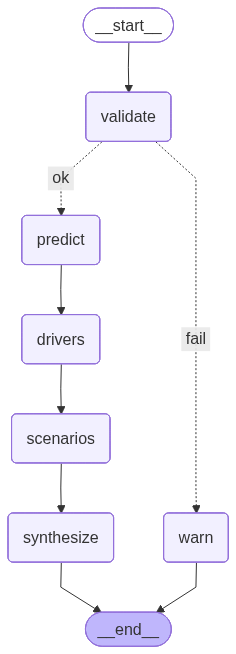

In [2]:
mermaid = graph.get_graph().draw_mermaid()
print(mermaid)
try:
    png = graph.get_graph().draw_mermaid_png()
    (resolve(cfg["paths"]["figures_dir"]) / "05_reasoning_graph.png").write_bytes(png)
    from IPython.display import Image, display
    display(Image(png))
except Exception as exc:
    print("(render PNG no disponible offline:", type(exc).__name__, "- queda el texto mermaid)")

## 2. Caso 1: estado operativo de referencia

El punto de operación es la mediana de las últimas 720 horas de entrenamiento, un estado típico de la
planta.

In [3]:
op_ref = default_operating_point(ctx)
show(graph.invoke({"input_features": op_ref}))

usó LLM: True
impacto: {"predicted_silica": 1.662, "persistence_baseline": 1.61, "vs_baseline": 0.052, "achievable_reduction": 0.02, "achievable_reduction_pct_range": 0.43}
drivers: ['% Silica Concentrate__lag1h', '% Silica Concentrate__mom1h', '% Silica Concentrate__lag2h', 'Flotation Column 02 Air Flow__mean__slope3h', 'Flotation Column 03 Air Flow__mean']

conclusiones:
Informe Operacional

Situación: La predicción de sílice es 1.662, comparada con la última medición de laboratorio de 1.61, lo que indica un cambio esperado de 0.052.

Drivers: Las variables que explican la predicción son: % Silica Concentrate__lag1h (SHAP 0.0299), % Silica Concentrate__mom1h (SHAP 0.0232), % Silica Concentrate__lag2h (SHAP 0.0119) que aumentan la sílice; y Flotation Column 02 Air Flow__mean__slope3h (SHAP -0.0079) que la reduce.

Escenarios evaluados: Se evaluaron Flotation Column 03 Air Flow__mean (efecto máximo 0.0174), Flotation Column 03 Level__mean (efecto máximo 0.0109) y Flotation Column 02 Le

El grafo valida la entrada, predice, identifica los drivers locales, evalúa palancas manipulables y
sintetiza un informe con impacto cuantificado. Toda cifra citada proviene del estado del grafo; si el
texto incluyera un número ajeno, el nodo de síntesis lo reportaría en `avisos`.

## 3. Caso 2: hora de sílice alta

Es el régimen operacionalmente crítico (peor calidad del concentrado) y donde el soporte a la decisión
aporta más.

In [4]:
preds = ctx.model.predict(ctx.X_ref)
op_high = ctx.X_ref.iloc[int(np.argmax(preds))].to_dict()
show(graph.invoke({"input_features": op_high}))

usó LLM: True
impacto: {"predicted_silica": 5.339, "persistence_baseline": 5.47, "vs_baseline": -0.131, "achievable_reduction": 0.043, "achievable_reduction_pct_range": 0.92}
drivers: ['% Silica Concentrate__lag1h', '% Silica Concentrate__mom1h', '% Silica Concentrate__lag2h', 'Flotation Column 06 Air Flow__mean__lag3h', 'Amina Flow__mean']

conclusiones:
Informe Operacional

Situación: La predicción de sílice es 5.339, comparada con la última medición de laboratorio de 5.47, lo que indica un cambio esperado de -0.131. Esto sugiere una reducción alcanzable de 0.043, equivalente al 0.92% del rango del target.

Drivers: Las variables que explican la predicción son: % Silica Concentrate__lag1h (-0.0517), % Silica Concentrate__mom1h (-0.0479), % Silica Concentrate__lag2h (-0.0327) y Flotation Column 06 Air Flow__mean__lag3h (-0.0089), todas con efecto negativo sobre la sílice.

Escenarios evaluados: Se evaluaron las palancas Flotation Column 04 Level__mean (efecto máximo 0.0237), Flotation

En un estado de sílice alta el grafo reporta la predicción frente a la última medición conocida y
prioriza las palancas más sensibles para reducirla. La recomendación es direccional: el propio informe
declara que el modelo es asociativo.

## 4. Caso 3: entrada inválida (arista condicional hacia `warn`)

Un caso realista de datos defectuosos: el punto de operación llega sin dos variables requeridas (el
flujo de amina y el hierro del alimento, por ejemplo por una falla del historiador de planta) y con un
pH de pulpa de 94, un error de digitación evidente porque el pH solo puede estar entre 0 y 14.

In [5]:
# Punto de operación con dos variables ausentes y un pH físicamente imposible.
op_bad = {k: v for k, v in op_ref.items() if k in ctx.expected_inputs}
op_bad.pop("Amina Flow__mean", None)
op_bad.pop("% Iron Feed", None)
op_bad["Ore Pulp pH__mean"] = 94.0
result_bad = graph.invoke({"input_features": op_bad})
show(result_bad)

usó LLM: False
avisos: ['entrada inválida: el grafo se desvió al nodo de advertencia']

conclusiones:
No se generaron conclusiones operacionales porque la validación de la entrada falló. Problemas detectados: (1) faltan variables de operación requeridas: % Iron Feed, Amina Flow__mean. (2) Ore Pulp pH__mean = 94 es físicamente imposible (rango válido: 0 a 14). Corrija estos valores y vuelva a ejecutar el análisis.


La validación nombra exactamente qué variables faltan y por qué el pH es inválido, y la arista
condicional desvía el flujo al nodo `warn`: no se emiten conclusiones operacionales sobre datos no
confiables, solo el diagnóstico accionable para corregir la entrada. Los features internos derivados
(lags, suavizados, ratios) no participan de esta validación: el grafo valida las variables de operación
que un ingeniero realmente entrega y completa el resto desde el punto de referencia.

## 5. Cierre

El grafo separa responsabilidades: los nodos calculan (predicción, atribuciones, escenarios) y el LLM
solo redacta sobre números verificados, con un formato fijo de informe operacional (situación, drivers,
escenarios, recomendación, riesgos). El modo determinístico garantiza la misma estructura sin
credenciales, y el caso inválido muestra que el sistema prefiere no opinar antes que opinar sobre datos
defectuosos.